Imports et chargements

In [10]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df_mat = pd.read_csv("../dataset/student-mat.csv")

df_por = pd.read_csv("../dataset/student-por.csv")

Ce bloc charge les datasets et les bibliothèques nécessaires pour l'ACP, en préparant l'environnement d'analyse.

Préparation ACP

Ce bloc prépare les données en encodant les variables catégorielles, en les standardisant et en calculant l'ACP pour chaque dataset.

In [11]:
datasets = {
    "Math": df_mat,
    "Portuguese": df_por
}

pca_results = {}

for name, df in datasets.items():

    df_encoded = pd.get_dummies(df, drop_first=True)

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(df_encoded)

    pca = PCA()

    X_pca = pca.fit_transform(X_scaled)

    pca_results[name] = {
        "df_encoded": df_encoded,
        "X_scaled": X_scaled,
        "pca": pca,
        "X_pca": X_pca
    }

Ce graphique permet de visualiser la variance expliquée par les composantes principales et d'identifier le nombre de dimensions à conserver.

Scree plots

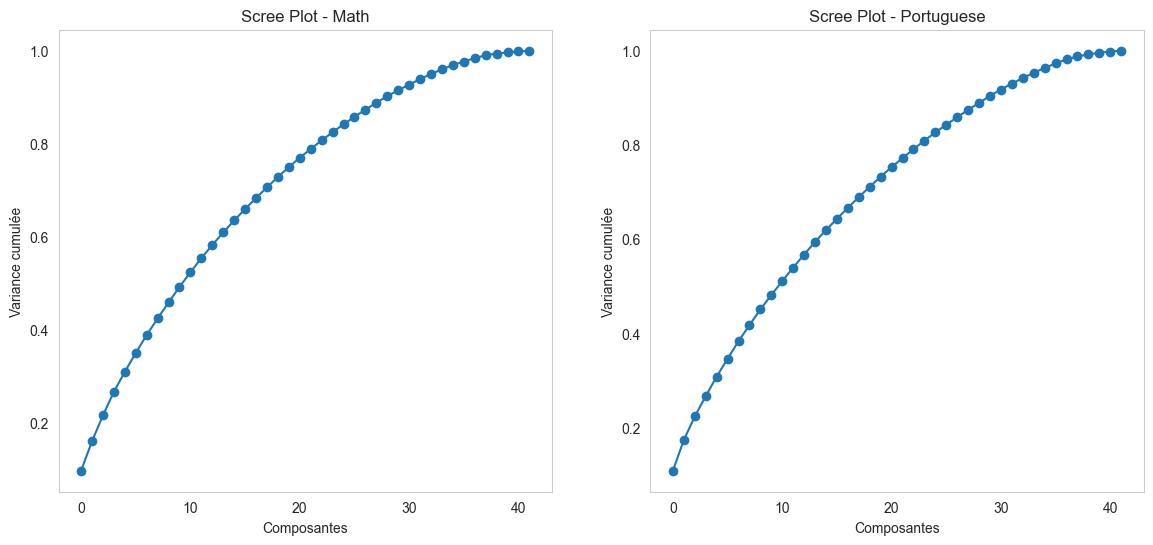

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

for ax, (name, result) in zip(axes, pca_results.items()):

    explained = result["pca"].explained_variance_ratio_

    ax.plot(
        np.cumsum(explained),
        marker='o'
    )

    ax.set_title(f"Scree Plot - {name}")

    ax.set_xlabel("Composantes")

    ax.set_ylabel("Variance cumulée")

    ax.grid()

plt.show()

## Analyse d'inertie - Détermination du nombre optimal de composantes

In [ ]:
### Analyse d'inertie et détermination du nombre optimal de composantes

print("=" * 80)
print("ANALYSE D'INERTIE - Détermination du nombre optimal de composantes")
print("=" * 80)

# Critère : on garde les composantes jusqu'à 80-90% de variance expliquée
threshold_variance = 0.85  # 85% de variance expliquée

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

optimal_components = {}

for idx, (name, result) in enumerate(pca_results.items()):
    pca_full = result["pca"]
    explained_var_ratio = pca_full.explained_variance_ratio_
    cumsum_var = np.cumsum(explained_var_ratio)
    
    # Trouver le nombre de composantes pour 85% de variance
    n_components_85 = np.argmax(cumsum_var >= threshold_variance) + 1
    
    # Trouver le "coude" (point où la variance expliquée commence à plafonner)
    # On calcule la différence entre composantes successives
    diffs = np.diff(explained_var_ratio)
    # Le coude est où la différence chute significativement
    threshold_diff = 0.01  # Au moins 1% de variance supplémentaire
    n_components_elbow = np.argmax(diffs < threshold_diff) + 2 if np.any(diffs < threshold_diff) else 5
    
    optimal_components[name] = {
        "n_85": n_components_85,
        "n_elbow": n_components_elbow,
        "var_85": cumsum_var[n_components_85-1] if n_components_85 <= len(cumsum_var) else cumsum_var[-1]
    }
    
    print(f"\n{name}:")
    print(f"  - Nombre total de features : {len(explained_var_ratio)}")
    print(f"  - Nombre de composantes pour 85% variance : {n_components_85} (variance : {cumsum_var[n_components_85-1]:.4f})")
    print(f"  - Nombre de composantes (coude) : {n_components_elbow} (variance : {cumsum_var[n_components_elbow-1]:.4f})")
    print(f"  - Variance expliquée par PC1 : {explained_var_ratio[0]:.4f}")
    print(f"  - Variance expliquée par PC1+PC2 : {cumsum_var[1]:.4f}")
    print(f"  - Variance expliquée par PC1+PC2+PC3 : {cumsum_var[2]:.4f}")
    
    # Plot 1 : Variance cumulée
    ax1 = axes[idx, 0]
    n_components_to_plot = min(50, len(cumsum_var))
    ax1.plot(range(1, n_components_to_plot+1), cumsum_var[:n_components_to_plot], 
            marker='o', linewidth=2, markersize=5, label='Variance cumulée')
    ax1.axhline(y=0.85, color='r', linestyle='--', linewidth=2, label='Seuil 85%')
    ax1.axvline(x=n_components_85, color='g', linestyle='--', linewidth=2, label=f'Optimal: {n_components_85} composantes')
    ax1.axvline(x=n_components_elbow, color='orange', linestyle=':', linewidth=2, label=f'Coude: {n_components_elbow} composantes')
    ax1.set_xlabel("Nombre de composantes")
    ax1.set_ylabel("Variance cumulée")
    ax1.set_title(f"Variance cumulée - {name}")
    ax1.legend()
    ax1.grid(alpha=0.3)
    ax1.set_ylim([0, 1.05])
    
    # Plot 2 : Variance par composante (en barres)
    ax2 = axes[idx, 1]
    n_to_show = min(20, len(explained_var_ratio))
    colors = ['#2ecc71' if i < n_components_85 else '#95a5a6' for i in range(n_to_show)]
    ax2.bar(range(1, n_to_show+1), explained_var_ratio[:n_to_show], color=colors, alpha=0.8, edgecolor='black')
    ax2.set_xlabel("Numéro de la composante")
    ax2.set_ylabel("Variance expliquée")
    ax2.set_title(f"Variance par composante - {name}")
    ax2.axhline(y=0.01, color='r', linestyle='--', linewidth=1, alpha=0.5, label='Seuil 1%')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("RECOMMANDATION : Nombre de composantes à utiliser")
print("=" * 80)

for name, info in optimal_components.items():
    print(f"\n{name}:")
    print(f"  → Réduction conseillée : {info['n_85']} composantes")
    print(f"     (Explique {info['var_85']:.1%} de la variance)")
    print(f"  → Réduction alternative (coude) : {info['n_elbow']} composantes")

In [ ]:
### ACP optimale avec réduction de dimension

print("\n" + "=" * 80)
print("ACP OPTIMALE - Réduction avec nombre optimal de composantes")
print("=" * 80)

# On utilise le critère 85% pour une bonne réduction
optimal_pca_results = {}

for name, result in pca_results.items():
    n_opt = optimal_components[name]["n_85"]
    
    # Refaire une ACP avec le nombre optimal
    pca_opt = PCA(n_components=n_opt)
    X_pca_opt = pca_opt.fit_transform(result["X_scaled"])
    
    optimal_pca_results[name] = {
        "pca_opt": pca_opt,
        "X_pca_opt": X_pca_opt,
        "n_components": n_opt
    }
    
    print(f"\n{name}:")
    print(f"  - Réduction : {len(result['X_scaled'][0])} → {n_opt} dimensions")
    print(f"  - Taux de compression : {n_opt / len(result['X_scaled'][0]) * 100:.1f}%")
    print(f"  - Variance conservée : {pca_opt.explained_variance_ratio_.sum():.2%}")

# Visualisation : Comparaison avant/après réduction
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (name, result) in enumerate(pca_results.items()):
    n_opt = optimal_components[name]["n_85"]
    
    # Nombre de dimensions avant et après
    before = len(result['X_scaled'][0])
    after = n_opt
    
    ax = axes[idx]
    
    # Barre pour avant/après
    categories = ['Avant\nréduction', 'Après\nréduction\n(optimal)']
    dimensions = [before, after]
    colors = ['#e74c3c', '#2ecc71']
    
    bars = ax.bar(categories, dimensions, color=colors, alpha=0.8, edgecolor='black', linewidth=2, width=0.5)
    
    # Ajouter les valeurs sur les barres
    for bar, dim in zip(bars, dimensions):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{dim} dim',
               ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    # Calculer le ratio de réduction
    reduction_ratio = (before - after) / before * 100
    variance_kept = optimal_pca_results[name]["pca_opt"].explained_variance_ratio_.sum()
    
    ax.set_ylabel("Nombre de dimensions", fontsize=11, fontweight='bold')
    ax.set_title(f"{name}\n{reduction_ratio:.0f}% de réduction | {variance_kept:.1%} variance conservée", 
                fontsize=12, fontweight='bold')
    ax.set_ylim(0, before * 1.1)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("✓ L'ACP optimale est prête pour les analyses suivantes")
print("=" * 80)

ACP 2D

Ce bloc prépare la projection des observations sur les deux premières composantes principales pour visualiser l'espace réduit.

In [13]:
pca_2d_results = {}

for name, result in pca_results.items():

    pca_2d = PCA(n_components=2)

    X_pca_2d = pca_2d.fit_transform(result["X_scaled"])

    pca_2d_results[name] = {
        "pca_2d": pca_2d,
        "X_pca_2d": X_pca_2d
    }

Projection ACP

Cette cellule trace la projection 2D des observations sur PC1 et PC2 pour analyser la structure des données.

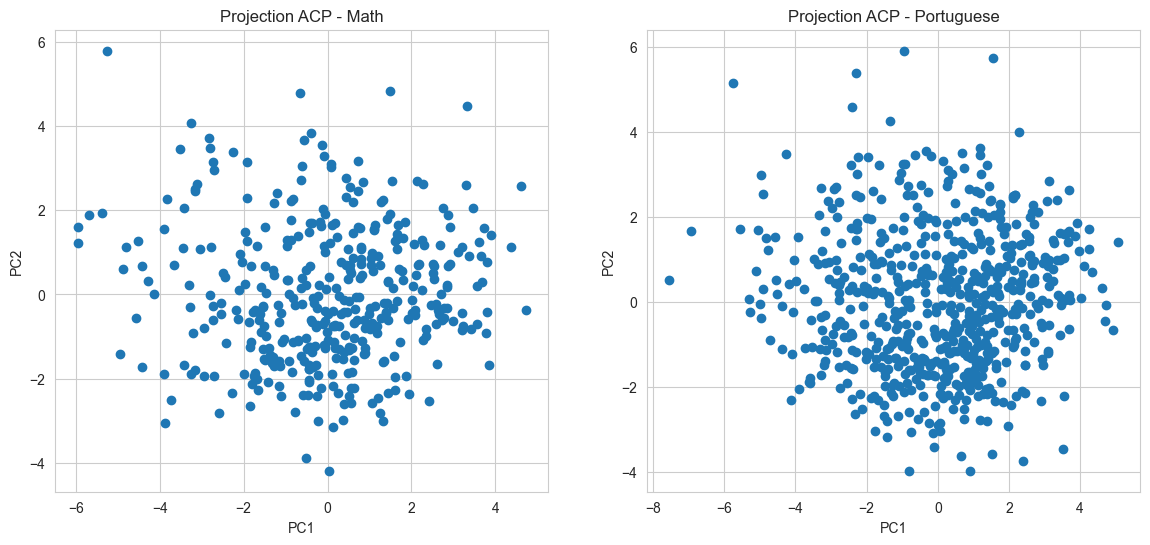

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

for ax, (name, result) in zip(axes, pca_2d_results.items()):

    X = result["X_pca_2d"]

    ax.scatter(
        X[:,0],
        X[:,1]
    )

    ax.set_title(f"Projection ACP - {name}")

    ax.set_xlabel("PC1")

    ax.set_ylabel("PC2")

plt.show()

ACP colorée par note

Cette visualisation colore la projection PCA selon G3, ce qui permet de voir si les notes finales se regroupent dans l'espace réduit.

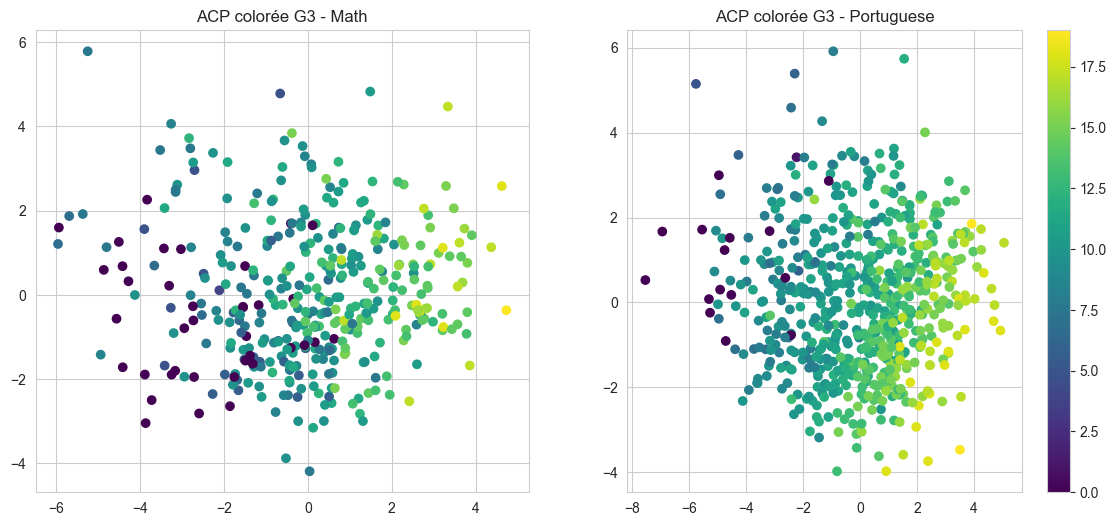

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

datasets_list = [
    ("Math", df_mat),
    ("Portuguese", df_por)
]

for ax, (name, df) in zip(axes, datasets_list):

    X = pca_2d_results[name]["X_pca_2d"]

    scatter = ax.scatter(
        X[:,0],
        X[:,1],
        c=df["G3"],
        cmap="viridis"
    )

    ax.set_title(f"ACP colorée G3 - {name}")

plt.colorbar(scatter)

plt.show()

## Analyse détaillée : Projections PCA par variable d'intérêt

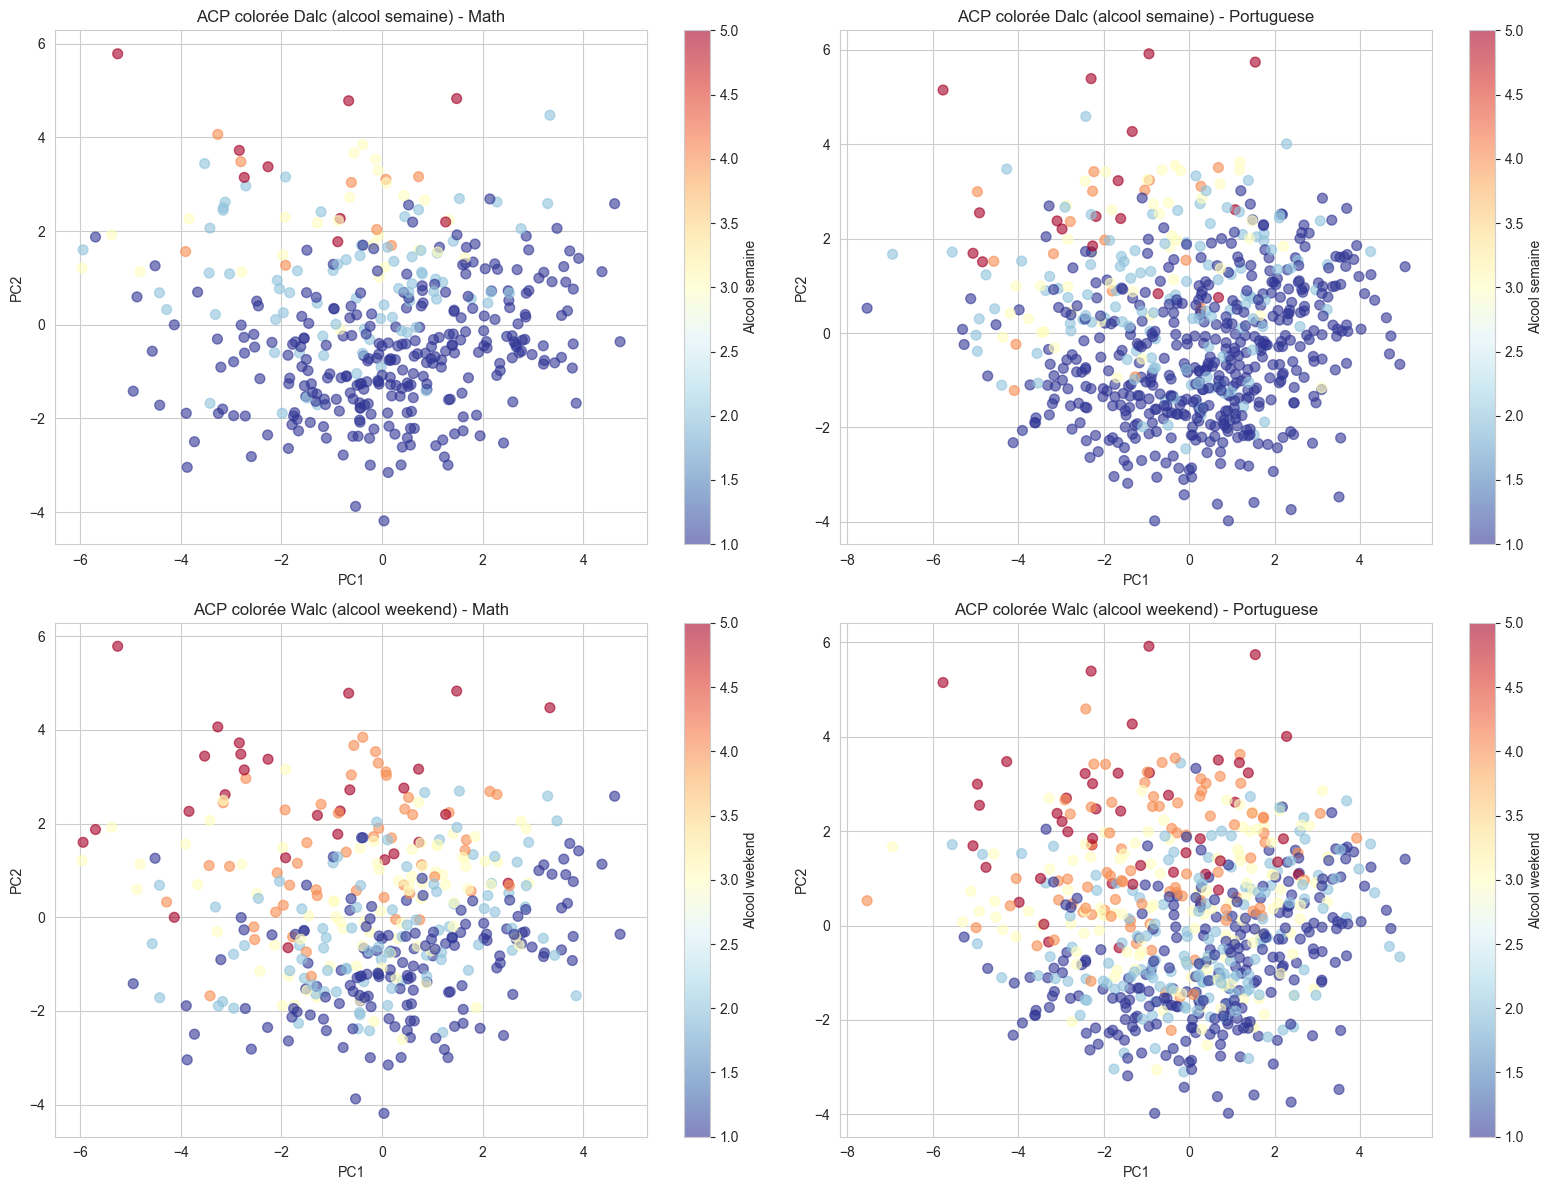

In [16]:
### ACP coloriée par Alcool (Jour et Weekend)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Workday alcohol (Dalc)
for idx, (name, df) in enumerate([("Math", df_mat), ("Portuguese", df_por)]):
    X = pca_2d_results[name]["X_pca_2d"]
    scatter = axes[0, idx].scatter(X[:,0], X[:,1], c=df["Dalc"], cmap="RdYlBu_r", s=50, alpha=0.6)
    axes[0, idx].set_title(f"ACP colorée Dalc (alcool semaine) - {name}")
    axes[0, idx].set_xlabel("PC1")
    axes[0, idx].set_ylabel("PC2")
    cbar = plt.colorbar(scatter, ax=axes[0, idx])
    cbar.set_label("Alcool semaine")

# Weekend alcohol (Walc)  
for idx, (name, df) in enumerate([("Math", df_mat), ("Portuguese", df_por)]):
    X = pca_2d_results[name]["X_pca_2d"]
    scatter = axes[1, idx].scatter(X[:,0], X[:,1], c=df["Walc"], cmap="RdYlBu_r", s=50, alpha=0.6)
    axes[1, idx].set_title(f"ACP colorée Walc (alcool weekend) - {name}")
    axes[1, idx].set_xlabel("PC1")
    axes[1, idx].set_ylabel("PC2")
    cbar = plt.colorbar(scatter, ax=axes[1, idx])
    cbar.set_label("Alcool weekend")

plt.tight_layout()
plt.show()

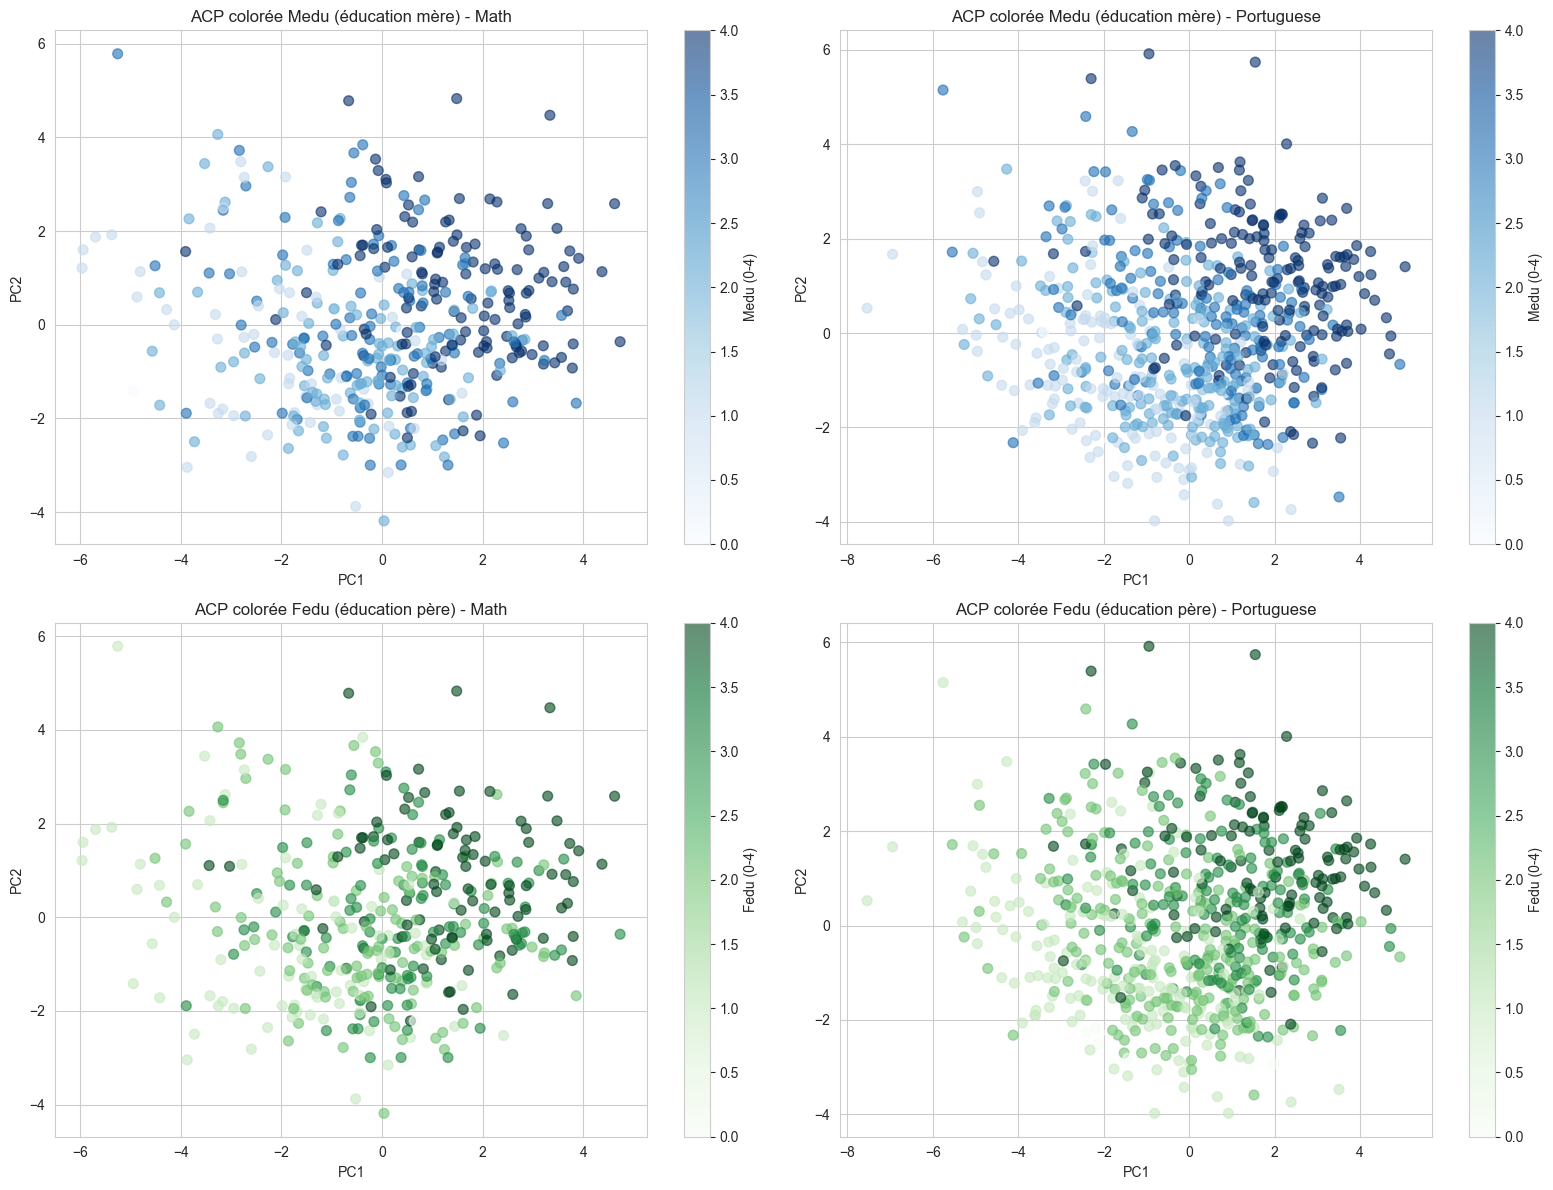

In [17]:
### ACP coloriée par Éducation des parents

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Mother education (Medu)
for idx, (name, df) in enumerate([("Math", df_mat), ("Portuguese", df_por)]):
    X = pca_2d_results[name]["X_pca_2d"]
    scatter = axes[0, idx].scatter(X[:,0], X[:,1], c=df["Medu"], cmap="Blues", s=50, alpha=0.6)
    axes[0, idx].set_title(f"ACP colorée Medu (éducation mère) - {name}")
    axes[0, idx].set_xlabel("PC1")
    axes[0, idx].set_ylabel("PC2")
    cbar = plt.colorbar(scatter, ax=axes[0, idx])
    cbar.set_label("Medu (0-4)")

# Father education (Fedu)
for idx, (name, df) in enumerate([("Math", df_mat), ("Portuguese", df_por)]):
    X = pca_2d_results[name]["X_pca_2d"]
    scatter = axes[1, idx].scatter(X[:,0], X[:,1], c=df["Fedu"], cmap="Greens", s=50, alpha=0.6)
    axes[1, idx].set_title(f"ACP colorée Fedu (éducation père) - {name}")
    axes[1, idx].set_xlabel("PC1")
    axes[1, idx].set_ylabel("PC2")
    cbar = plt.colorbar(scatter, ax=axes[1, idx])
    cbar.set_label("Fedu (0-4)")

plt.tight_layout()
plt.show()

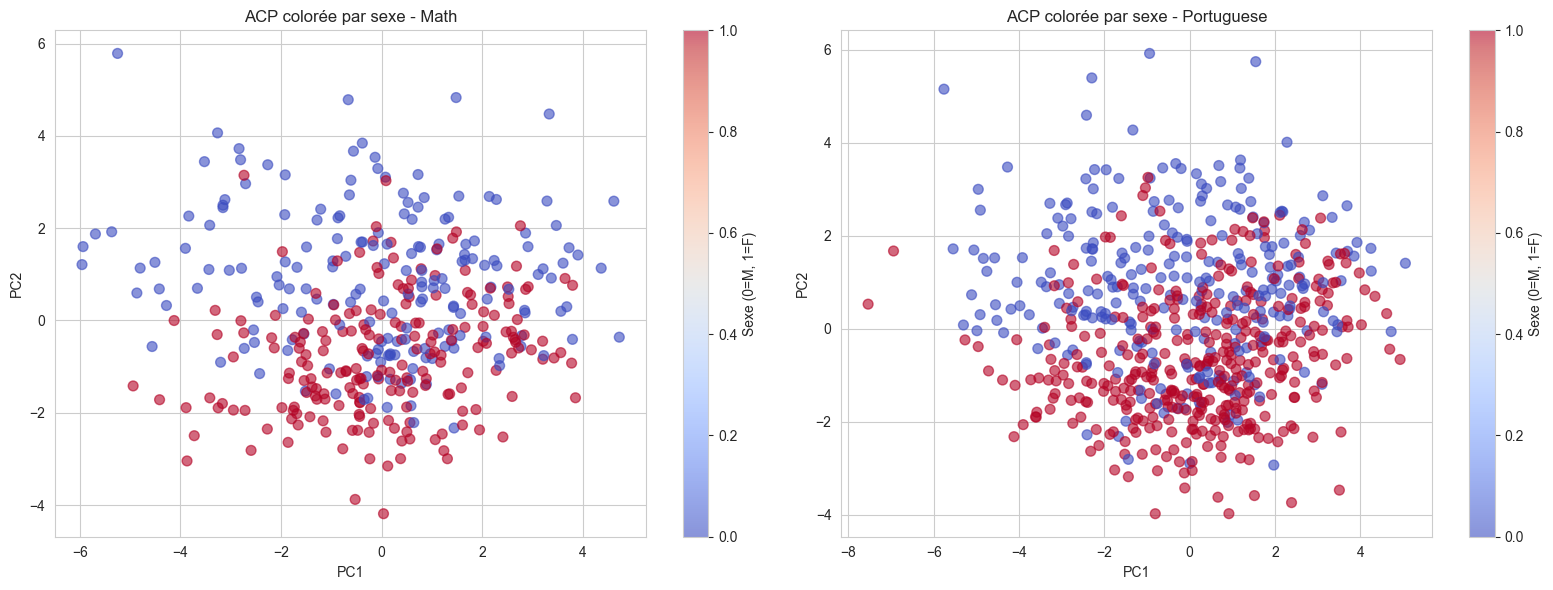

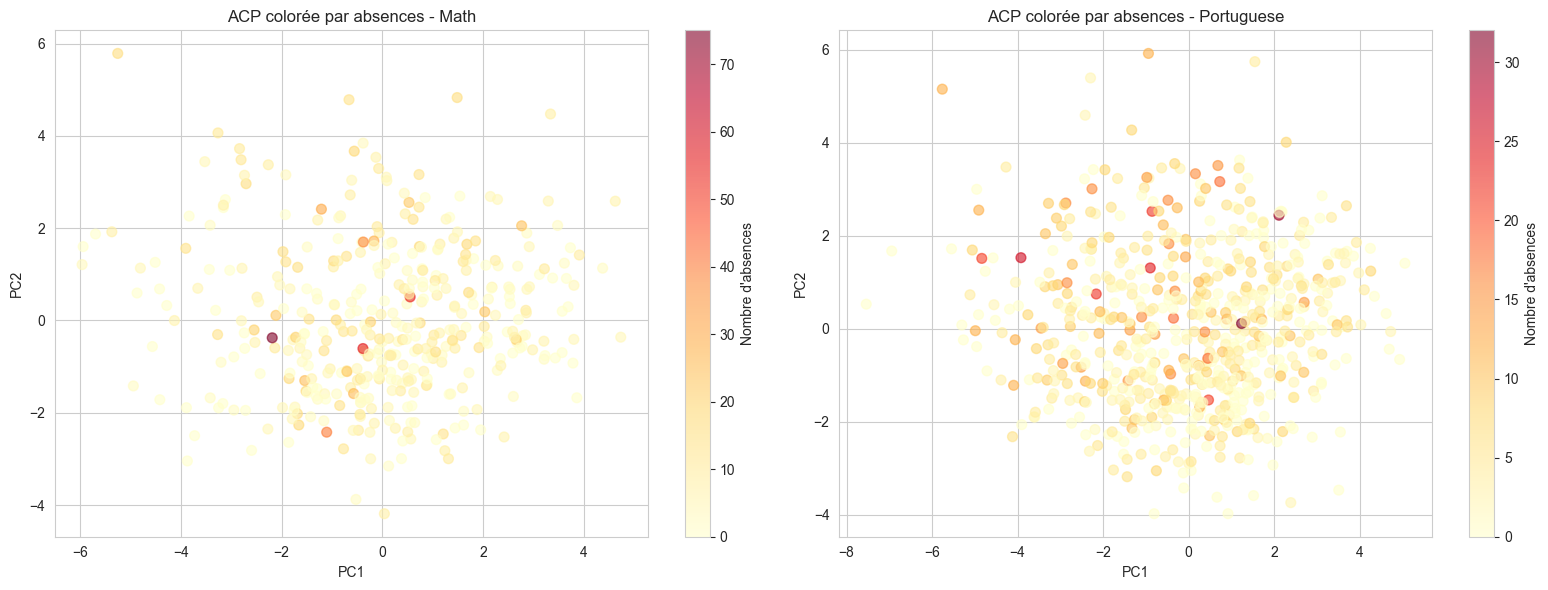

In [18]:
### ACP coloriée par Sexe de l'étudiant

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (name, df) in enumerate([("Math", df_mat), ("Portuguese", df_por)]):
    X = pca_2d_results[name]["X_pca_2d"]
    # Convert sex to numeric (M=0, F=1)
    sex_numeric = (df["sex"] == "F").astype(int)
    scatter = axes[idx].scatter(X[:,0], X[:,1], c=sex_numeric, cmap="coolwarm", s=50, alpha=0.6)
    axes[idx].set_title(f"ACP colorée par sexe - {name}")
    axes[idx].set_xlabel("PC1")
    axes[idx].set_ylabel("PC2")
    cbar = plt.colorbar(scatter, ax=axes[idx])
    cbar.set_label("Sexe (0=M, 1=F)")

plt.tight_layout()
plt.show()

### ACP coloriée par Absences

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (name, df) in enumerate([("Math", df_mat), ("Portuguese", df_por)]):
    X = pca_2d_results[name]["X_pca_2d"]
    scatter = axes[idx].scatter(X[:,0], X[:,1], c=df["absences"], cmap="YlOrRd", s=50, alpha=0.6)
    axes[idx].set_title(f"ACP colorée par absences - {name}")
    axes[idx].set_xlabel("PC1")
    axes[idx].set_ylabel("PC2")
    cbar = plt.colorbar(scatter, ax=axes[idx])
    cbar.set_label("Nombre d'absences")

plt.tight_layout()
plt.show()

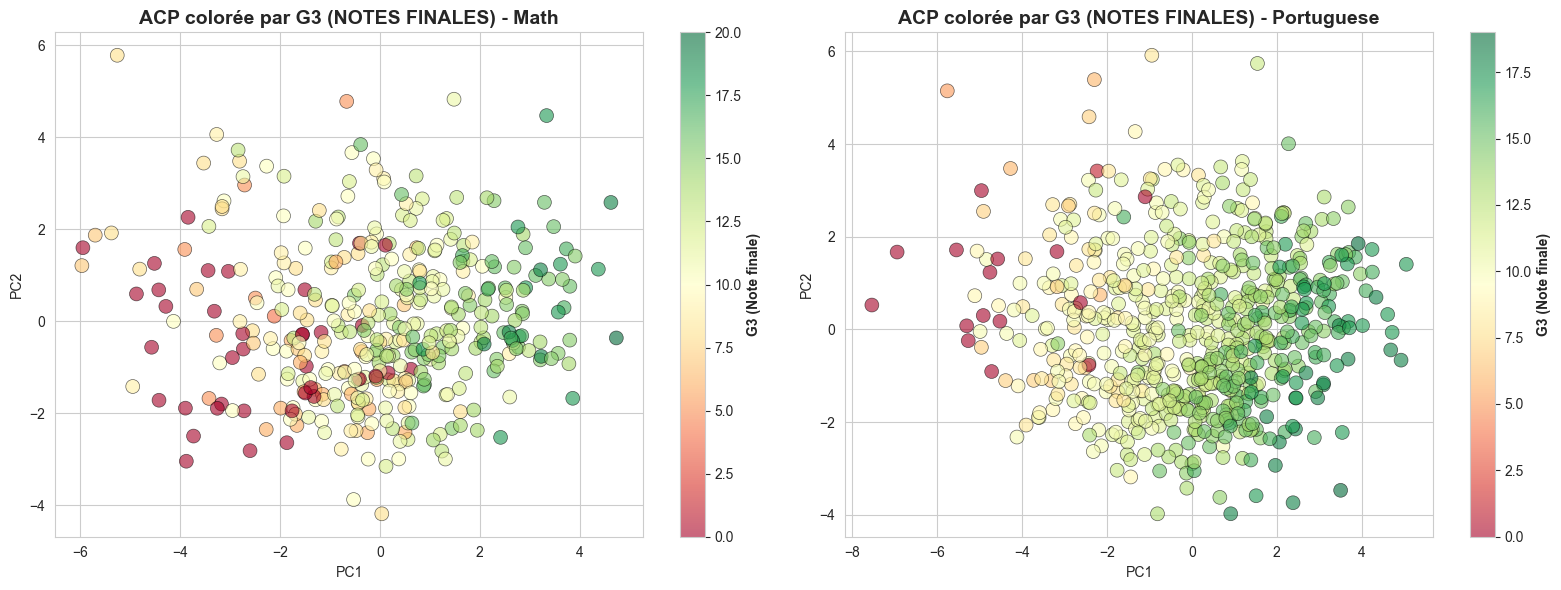


INTERPRÉTATION : La couleur du point montre la note finale (G3)
- Rouge = Mauvaise note, Jaune = Moyen, Vert = Bonne note
Les patterns dans les projections PCA révèlent comment les
variables latentes (combinaisons de features) influencent G3


In [19]:
### ACP coloriée par G3 (IMPACT DIRECT SUR LES NOTES)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (name, df) in enumerate([("Math", df_mat), ("Portuguese", df_por)]):
    X = pca_2d_results[name]["X_pca_2d"]
    scatter = axes[idx].scatter(X[:,0], X[:,1], c=df["G3"], cmap="RdYlGn", s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
    axes[idx].set_title(f"ACP colorée par G3 (NOTES FINALES) - {name}", fontsize=14, fontweight='bold')
    axes[idx].set_xlabel("PC1")
    axes[idx].set_ylabel("PC2")
    cbar = plt.colorbar(scatter, ax=axes[idx])
    cbar.set_label("G3 (Note finale)", fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("INTERPRÉTATION : La couleur du point montre la note finale (G3)")
print("- Rouge = Mauvaise note, Jaune = Moyen, Vert = Bonne note")
print("Les patterns dans les projections PCA révèlent comment les")
print("variables latentes (combinaisons de features) influencent G3")
print("="*60)